In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
# Load only the train split — this is the dataset we work with throughout
print("Loading CNN/DailyMail train split...")
ds = load_dataset("abisee/cnn_dailymail", "1.0.0")
df_train = ds["train"].to_pandas()

print(f"Train articles : {len(df_train):,}")
print(f"Columns        : {df_train.columns.tolist()}")

C:\Users\ASUS\anaconda3\envs\topic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CNN/DailyMail train split...


Train articles : 287,113
Columns        : ['article', 'highlights', 'id']


In [10]:
# Load NER results — contains 'id' and 'primary_country' (ISO2 code)
ner = pd.read_parquet(
    "ner_results_final.parquet",
    columns=["id", "primary_country"]
)

topic_coverage = pd.read_csv(
    "topic_classification_articles.csv",
    usecols=["id", "theme", "news_type", "confidence"]
)

# Load structural factors dataset — contains iso2, country, global_north_or_south
structural = pd.read_csv("StructuralFactorsOfCountries.csv")

# Step 1: merge with NER on article id
df = df_train.merge(ner[["id", "primary_country"]], on="id", how="inner")

# Step 2: merge with structural factors, primary_country (ISO2) matches iso2
df = df.merge(
    structural[["iso2", "country", "global_north_or_south"]],
    left_on="primary_country",
    right_on="iso2",
    how="left"
)

# Step 3: merge with topic coverage
df = df.merge(topic_coverage, on="id", how="left")
    

Merged dataset shape: (81570, 10)

Global North/South counts:
global_north_or_south
Global North    54338
Global South    23044
Name: count, dtype: int64

Articles without a country match: 4,188

Preview:


,id,primary_country,country,global_north_or_south,theme,news_type,confidence
10,017d27d00eb43678c15cb4a8dd4723a035323219,IQ,Iraq,Global South,Politics & Conflict,Hard news,0.9962
12,77d7c8cf2a9432e395d629371a12790c563c19f7,DE,Germany,Global North,Sports & Entertainment,Soft news,0.9905
16,bf0cd4ccacd4fe045995338f4c44d9cf18000226,DZ,Algeria,Global South,Politics & Conflict,Hard news,0.9756
17,2f43e9dfaa43ffbddbce339a8b6403ddce43b38a,GB,United Kingdom,Global North,Sports & Entertainment,Soft news,0.9610
23,fbc6a4d0697b2a3e8b549dcb1f80a8ce7bf47e34,ES,Spain,Global North,Sports & Entertainment,Soft news,0.9793


In [17]:
# Remove confidence scores below 0.9 as to ensure higher accuracy
df = df[df["confidence"] >= 0.9]

print(f"Merged dataset shape: {df.shape}")
print(f"\nGlobal North/South counts:")
print(df["global_north_or_south"].value_counts())
print(f"\nArticles without a country match: {df['global_north_or_south'].isna().sum():,}")
print(f"\nPreview:")
df[["id", "primary_country", "country", "global_north_or_south", "theme", "news_type", "confidence"]].head()

Merged dataset shape: (81570, 10)

Global North/South counts:
global_north_or_south
Global North    54338
Global South    23044
Name: count, dtype: int64

Articles without a country match: 4,188

Preview:


,id,primary_country,country,global_north_or_south,theme,news_type,confidence
10,017d27d00eb43678c15cb4a8dd4723a035323219,IQ,Iraq,Global South,Politics & Conflict,Hard news,0.9962
12,77d7c8cf2a9432e395d629371a12790c563c19f7,DE,Germany,Global North,Sports & Entertainment,Soft news,0.9905
16,bf0cd4ccacd4fe045995338f4c44d9cf18000226,DZ,Algeria,Global South,Politics & Conflict,Hard news,0.9756
17,2f43e9dfaa43ffbddbce339a8b6403ddce43b38a,GB,United Kingdom,Global North,Sports & Entertainment,Soft news,0.9610
23,fbc6a4d0697b2a3e8b549dcb1f80a8ce7bf47e34,ES,Spain,Global North,Sports & Entertainment,Soft news,0.9793


In [11]:
# Save the enriched dataset with country and North/South columns
# Only rows with a matched country are saved
df_ns = df.dropna(subset=["global_north_or_south"]).copy()

output_cols = ["id", "primary_country", "country", "global_north_or_south",
               "theme", "news_type", "confidence"]
df_ns[output_cols].to_csv("topic_classification_with_country.csv", index=False, encoding="utf-8-sig")

print(f"Saved: topic_classification_with_country.csv")
print(f"  Rows    : {len(df_ns):,}")
print(f"  Columns : {output_cols}")

Saved: topic_classification_with_country.csv
  Rows    : 77,382
  Columns : ['id', 'primary_country', 'country', 'global_north_or_south', 'theme', 'news_type', 'confidence']


In [12]:
colors_ns   = {"Global North": "#3498db", "Global South": "#e67e22"}
THEME_ORDER = [
    "Politics & Conflict", "Crisis, Disaster & Accidents", "Crime & Law",
    "Sports & Entertainment", "Culture & Lifestyle", "Business, Science & Technology"
]
THEME_COLORS = {
    "Politics & Conflict"           : "#922B21",
    "Crisis, Disaster & Accidents"  : "#E74C3C",
    "Crime & Law"                   : "#F1948A",
    "Sports & Entertainment"        : "#1A5276",
    "Culture & Lifestyle"           : "#2E86C1",
    "Business, Science & Technology": "#85C1E9",
}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
print("Visualisation setup ready.")

Visualisation setup ready.


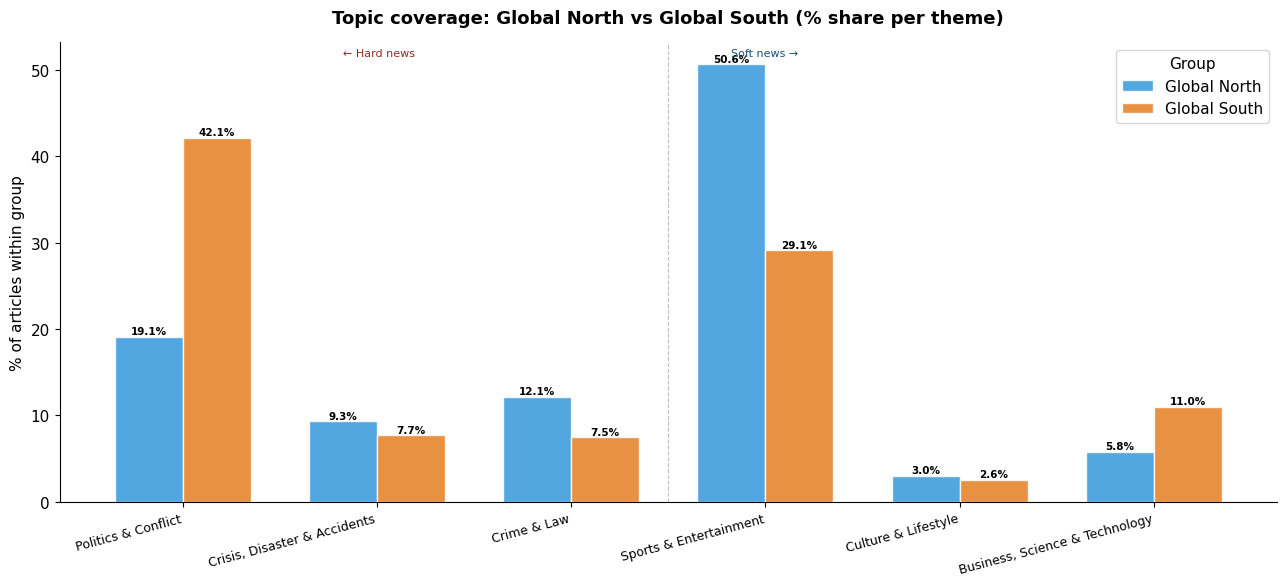

In [13]:
# Plot 1 — Theme distribution (%) by Global North vs Global South
# Shows what proportion of each group's articles falls into each theme.

theme_by_ns = (
    df_ns.groupby(["global_north_or_south", "theme"])
    .size().unstack(fill_value=0)
    .reindex(columns=THEME_ORDER)
)
theme_by_ns_pct = theme_by_ns.div(theme_by_ns.sum(axis=1), axis=0) * 100

x = np.arange(len(THEME_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
groups = theme_by_ns_pct.index.tolist()

for i, group in enumerate(groups):
    vals = theme_by_ns_pct.loc[group].values
    bars = ax.bar(x + i * width, vals, width=width,
                  label=group, color=colors_ns[group], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 1.5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{val:.1f}%", ha="center", fontsize=7.5, fontweight="bold")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(THEME_ORDER, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("% of articles within group")
ax.set_title("Topic coverage: Global North vs Global South (% share per theme)",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(title="Group")

# Hard/soft divider
ax.axvline(x=2.5 + width / 2, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.text(1.0, ax.get_ylim()[1] * 0.97, "← Hard news", color="#922B21", fontsize=8)
ax.text(3.0, ax.get_ylim()[1] * 0.97, "Soft news →", color="#1A5276", fontsize=8)

plt.tight_layout()
plt.savefig("plot_ns_theme_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

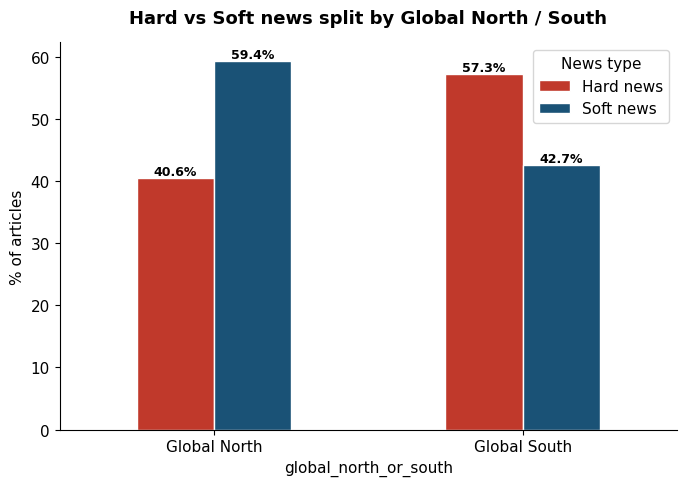

In [14]:
# Plot 2 — Hard news vs Soft news split by North/South
# Shows whether one group has more hard or soft news coverage.

hard_soft = (
    df_ns.groupby(["global_north_or_south", "news_type"])
    .size().unstack(fill_value=0)
)
hard_soft_pct = hard_soft.div(hard_soft.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))
hard_soft_pct.plot(
    kind="bar", ax=ax,
    color=["#C0392B", "#1A5276"],
    edgecolor="white", width=0.5
)
ax.set_xticklabels(hard_soft_pct.index, rotation=0)
ax.set_ylabel("% of articles")
ax.set_title("Hard vs Soft news split by Global North / South",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(title="News type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_ns_hard_soft.png", dpi=150, bbox_inches="tight")
plt.show()

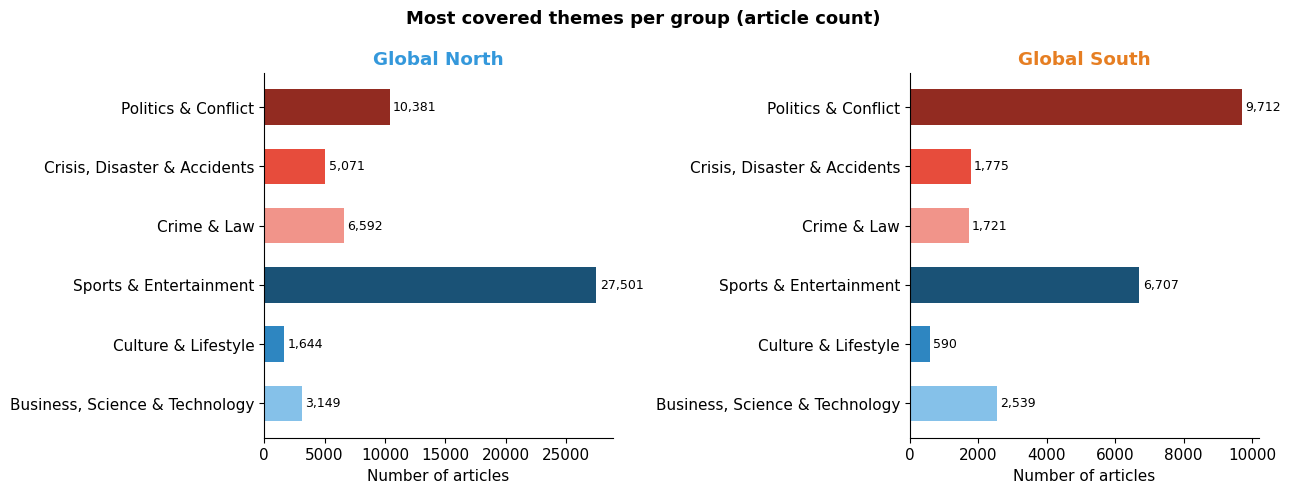

In [15]:
# Plot 3 — Top 3 dominant themes for each group (raw article counts)
# Highlights what each group is most covered about.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Most covered themes per group (article count)",
             fontsize=13, fontweight="bold")

for ax, group in zip(axes, ["Global North", "Global South"]):
    subset = df_ns[df_ns["global_north_or_south"] == group]
    counts = subset["theme"].value_counts().reindex(THEME_ORDER)
    colors = [THEME_COLORS[t] for t in counts.index]

    bars = ax.barh(counts.index, counts.values, color=colors, height=0.6)
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_width() + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", fontsize=9
        )
    ax.set_title(group, fontweight="bold", color=colors_ns[group])
    ax.set_xlabel("Number of articles")
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot_ns_top_themes.png", dpi=150, bbox_inches="tight")
plt.show()

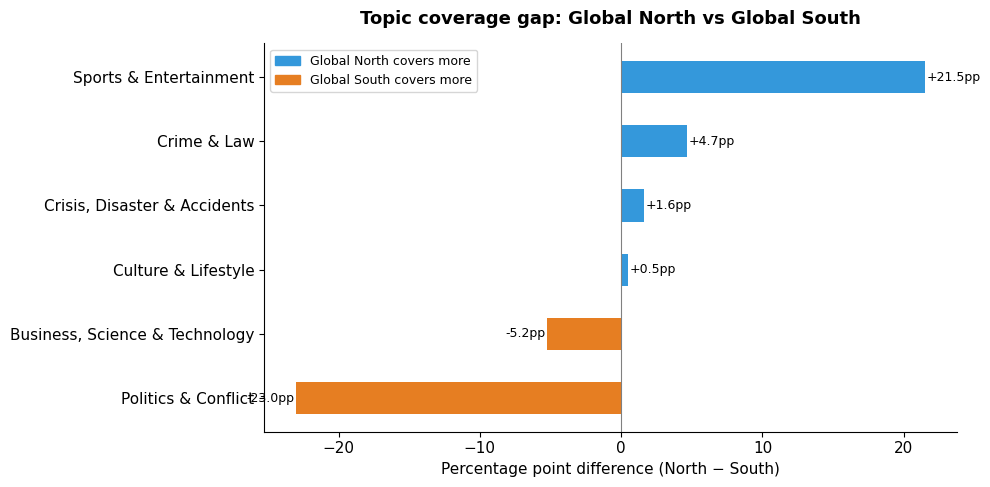

In [16]:
# Plot 4 — Coverage gap heatmap (Global North % - Global South %)
# Positive = North covers this more; Negative = South covers this more.

import seaborn as sns

gap = theme_by_ns_pct.loc["Global North"] - theme_by_ns_pct.loc["Global South"]
gap_df = gap.reset_index()
gap_df.columns = ["theme", "gap"]
gap_df = gap_df.sort_values("gap")

colors_gap = ["#e67e22" if v < 0 else "#3498db" for v in gap_df["gap"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(gap_df["theme"], gap_df["gap"], color=colors_gap, height=0.5)
ax.axvline(0, color="grey", linewidth=0.8)

for bar, val in zip(bars, gap_df["gap"]):
    x_pos = bar.get_width() + 0.1 if val >= 0 else bar.get_width() - 0.1
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}pp", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

north_patch = mpatches.Patch(color="#3498db", label="Global North covers more")
south_patch = mpatches.Patch(color="#e67e22", label="Global South covers more")
ax.legend(handles=[north_patch, south_patch], fontsize=9)
ax.set_xlabel("Percentage point difference (North − South)")
ax.set_title("Topic coverage gap: Global North vs Global South",
             fontsize=13, fontweight="bold", pad=14)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot_ns_coverage_gap.png", dpi=150, bbox_inches="tight")
plt.show()